# RMSD and Pearson

We compare one cluster against the reference profiles, choose the best match with each metric, and draw **one plot per code cell**. All calculations are included here. We use SingleR's reference data but do not run SingleR.

Select a Python kernel on The Beast with numpy, pandas and matplotlib, then click **Run All**. Reading the reference also requires `Rscript` and the R package SummarizedExperiment. Change `cluster_number` below to examine another cluster.

The p2 example is a demonstration, not an independent accuracy test: the reference also contains Zilionis data, including p2. Select the correct Gsell data and reference for the research comparison. ASTRID's SingleR uses Spearman; this notebook compares RMSD and Pearson.

The default project folder is `/scratch/adrian.sohrabi/astrid`. Paths assume the same layout inside the repository as on the local computer. Saved tables and figures were generated from a **local p2 run** with the project path temporarily changed for testing. Execution on The Beast has not yet been verified.


## 1. Choose files and a cluster

`cluster_number = 2` selects the second row of the pseudobulk file. Leave `expert_label = None` until you have the expert's annotation.


In [1]:
from pathlib import Path
import subprocess
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Repository root on The Beast. Change only this line when running locally.
project = Path("/scratch/adrian.sohrabi/astrid")

pseudobulk_file = project / "adrian_spec/test_run/p2_outASTRID_clustering_level_11_pseudobulk_matrix.csv"
reference_file = project / "data/ASTRID_SingleR_Reference_20240701.Rds"
exclusion_file = project / "data/excludeSingleR.csv"  # Human reference exclusions. None = no filter.
cluster_number = 2
expert_label = None  # Example: "macrophages", if that is the expert annotation.

assert pseudobulk_file.exists() and reference_file.exists(), "Check the project folder and input file paths on the server."


AssertionError: Check the project folder and input file paths on the server.

## 2. Read the data

Python reads the pseudobulk CSV directly. R reads the RDS reference and passes it to Python. This is file loading only; no `SingleR(...)` call is made. Temporary CSV files are deleted automatically. You normally do not need to change this cell.


In [ ]:
pseudobulk = pd.read_csv(pseudobulk_file, index_col=0)
pseudobulk.index = pseudobulk.index.astype(str)

r_code = r"""
suppressPackageStartupMessages(library(SummarizedExperiment))
a <- commandArgs(TRUE)
ref <- readRDS(a[1])
if (nzchar(a[4])) {
    excluded <- read.csv(a[4])$samples
    ref <- ref[, !colnames(ref) %in% excluded]
}
write.csv(as.matrix(assay(ref, "counts")), a[2])
write.csv(data.frame(cell_type = as.character(ref$cellTypeGRINT),
                     row.names = colnames(ref)), a[3])
"""
with tempfile.TemporaryDirectory() as folder:
    counts_file = Path(folder) / "counts.csv"
    labels_file = Path(folder) / "labels.csv"
    process = subprocess.run(
        ["Rscript", "-e", r_code, str(reference_file), str(counts_file),
         str(labels_file), str(exclusion_file) if exclusion_file is not None else ""],
        capture_output=True, text=True,
    )
    if process.returncode != 0:
        raise RuntimeError(process.stderr)
    reference = pd.read_csv(counts_file, index_col=0).T  # Reference profiles x genes.
    labels = pd.read_csv(labels_file, index_col=0)["cell_type"].reindex(reference.index)

assert pseudobulk.index.is_unique and reference.index.is_unique
assert pseudobulk.columns.is_unique and reference.columns.is_unique
assert labels.notna().all(), "Some references have no cell type."
print(f"Loaded {len(pseudobulk)} clusters and {len(reference)} reference profiles.")


Loaded 79 clusters and 888 reference profiles.


## 3. Use the same genes and scale

`x` contains the cluster's expression values. `reference` has one reference profile per row.

We use all shared genes in the same order. Unlogged counts/abundances are normalized to 100,000 and log-transformed, following ASTRID's annotation step. Both metrics receive the same data.


In [ ]:
assert 1 <= cluster_number <= len(pseudobulk), "The requested cluster row does not exist."
cluster_name = pseudobulk.index[cluster_number - 1]

genes = pseudobulk.columns.intersection(reference.columns, sort=False)
assert len(genes) >= 3, "Too few shared genes."
x = pseudobulk.iloc[cluster_number - 1].loc[genes].astype(float)
reference = reference.loc[:, genes].astype(float)

# Check that the input can be normalized.
assert np.isfinite(x).all() and np.isfinite(reference.to_numpy()).all()
assert (x >= 0).all() and (reference.to_numpy() >= 0).all()
assert x.sum() > 0 and (reference.sum(axis=1) > 0).all()

x = np.log10(1 + 100000 * x / x.sum())
reference = np.log10(1 + 100000 * reference.div(reference.sum(axis=1), axis=0))

print("Cluster:", cluster_name)
print("Shared genes:", len(genes))
print("Reference profiles:", len(reference))


Cluster: 0_0_0_0_1
Shared genes: 29307
Reference profiles: 888


## 4. Calculate RMSD and Pearson

The loop compares each reference profile with the same cluster and calculates both metrics. `np.corrcoef(x, profile)[0, 1]` returns their Pearson correlation. Constant expression produces an undefined Pearson correlation (`NaN`).


In [ ]:
rmsd = []
pearson = []

for name, profile in reference.iterrows():
    rmsd.append(np.sqrt(np.mean((x - profile) ** 2)))
    pearson.append(np.corrcoef(x, profile)[0, 1])

results = pd.DataFrame({
    "cell_type": labels,
    "RMSD": rmsd,
    "Pearson": pearson,
}, index=reference.index)
results.index.name = "reference"


## 5. Choose the best reference

This is where the selection happens: **lowest RMSD** and **highest Pearson**. The table shows both metrics for both winners. Exact ties select the first reference in file order; all scores remain available in `results`. Undefined Pearson values are skipped.


In [ ]:
assert results["Pearson"].notna().any(), "No valid Pearson correlation for this cluster."

best_rmsd = results["RMSD"].idxmin()
best_pearson = results["Pearson"].idxmax()

winners = results.loc[[best_rmsd, best_pearson]].copy()
winners.insert(0, "selected_by", ["RMSD", "Pearson"])
if expert_label is not None:
    winners["expert_label"] = expert_label
    winners["matches_expert"] = winners["cell_type"] == expert_label

display(winners.round(4))

# Use the same axis limits for both plots.
axis_max = max(x.max(), reference.loc[best_rmsd].max(), reference.loc[best_pearson].max()) * 1.05


,selected_by,cell_type,RMSD,Pearson
reference,,,,
inflammatory.macrophage.5,RMSD,macrophages,0.3875,0.4546
Patient.p2-cell_type.macrophages,Pearson,macrophages,0.4339,0.5324


## 6. Best RMSD match

Each point is a gene. The red line represents identical expression in the cluster and reference. Both metric values appear in the title.


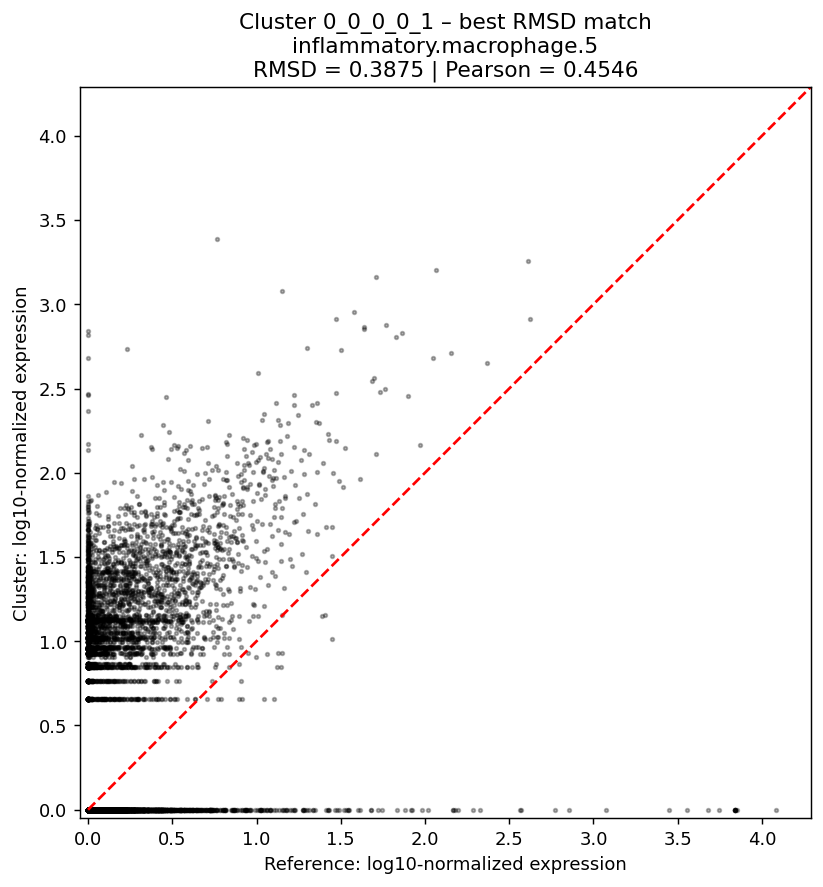

In [ ]:
profile = reference.loc[best_rmsd]
scores = results.loc[best_rmsd]

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(profile, x, s=4, alpha=0.3, color="black")
ax.plot([0, axis_max], [0, axis_max], "r--")
ax.set_xlim(-0.05, axis_max)
ax.set_ylim(-0.05, axis_max)
ax.set_aspect("equal")
ax.set_xlabel("Reference: log10-normalized expression")
ax.set_ylabel("Cluster: log10-normalized expression")
ax.set_title(f"Cluster {cluster_name} – best RMSD match\n"
             f"{best_rmsd}\n"
             f"RMSD = {scores.RMSD:.4f} | Pearson = {scores.Pearson:.4f}")
fig.tight_layout()
display(fig)
plt.close(fig)


## 7. Best Pearson match

The same cluster and axis limits, now paired with the reference chosen by Pearson. Each plot has its own code cell to keep the code easy to read.


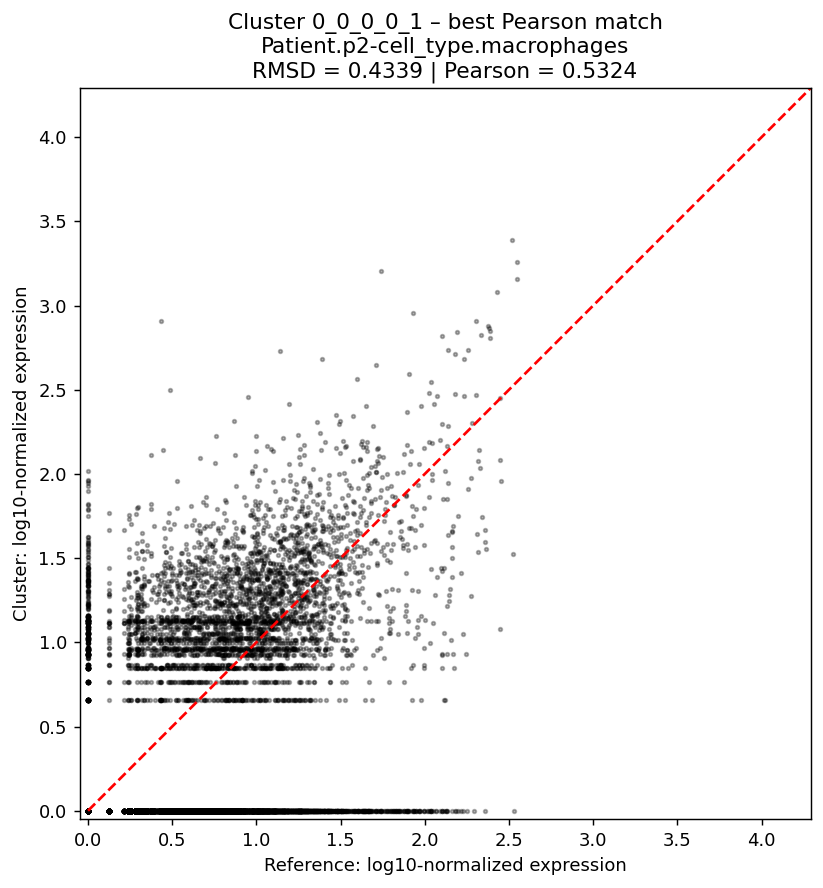

In [ ]:
profile = reference.loc[best_pearson]
scores = results.loc[best_pearson]

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(profile, x, s=4, alpha=0.3, color="black")
ax.plot([0, axis_max], [0, axis_max], "r--")
ax.set_xlim(-0.05, axis_max)
ax.set_ylim(-0.05, axis_max)
ax.set_aspect("equal")
ax.set_xlabel("Reference: log10-normalized expression")
ax.set_ylabel("Cluster: log10-normalized expression")
ax.set_title(f"Cluster {cluster_name} – best Pearson match\n"
             f"{best_pearson}\n"
             f"RMSD = {scores.RMSD:.4f} | Pearson = {scores.Pearson:.4f}")
fig.tight_layout()
display(fig)
plt.close(fig)


## Notes for the PI meeting

- Do the metrics choose different references? Do they also choose different cell types?
- How do the plots differ? Many points overlap, especially at zero.
- If an expert annotation is available, does the predicted cell type agree with it?

**Observation:** …

**Questions:** …

Choosing different references does not automatically mean one metric identifies cell types better. For p2 cluster 2, both methods suggest macrophages but choose different fingerprints.

Change `cluster_number` and select **Run All** to examine another cluster. Save with **Cmd + S** to keep the plots and table for the meeting. You can save a separate copy of the notebook for each cluster.
